In [2]:
%pip install numpy matplotlib scipy pandas

Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import pandas as pd

# Dataset creation- single one

In [4]:
# ==========================================
# 1. DEFINE PARAMETERS (Quarter Car)
# ==========================================
# Standard values for a passenger car
ms = 250.0   # Sprung mass (kg) - 1/4 of car body
mu = 35.0    # Unsprung mass (kg) - Tire + Wheel
ks = 10000.0 # Suspension stiffness (N/m)
bs = 1000.0  # Suspension damping (N*s/m)
ku = 150000.0# Tire stiffness (N/m)

In [5]:
# ==========================================
# 2. STATE SPACE MATRICES (From MPC Slide)
# ==========================================
# State x = [zs-zu,  zs_dot,  zu-zr,  zu_dot]^T
# x1: Suspension deflection
# x2: Sprung mass velocity
# x3: Tire deflection
# x4: Unsprung mass velocity

# Matrix A (System Matrix)
A = np.array([
    [0, 1, 0, -1],
    [-ks/ms, -bs/ms, 0, bs/ms],
    [0, 0, 0, 1],
    [ks/mu, bs/mu, -ku/mu, -bs/mu]
])

# Matrix B (Control Input Matrix - Force F)
B = np.array([
    [0],
    [1/ms],
    [0],
    [-1/mu]
])

# Matrix B_w (Disturbance Input Matrix - Road Velocity zr_dot)
B_w = np.array([
    [0],
    [0],
    [-1],
    [0]
])

In [6]:
# ==========================================
# 3. DEFINE INPUTS (Road & Control)
# ==========================================
def road_profile(t):
    # Let's create a "Bump" followed by random roughness
    if 1.0 < t < 1.5:
        return 0.1  # 10 cm/s upward velocity (bump)
    else:
        return 0.05 * np.sin(2 * np.pi * 5 * t) # Rough road (5Hz vibration)

def control_input(t):
    # For now, we use a simple "Passive" system (u=0)
    # OR we can add random control actions to generate training data
    # Let's add a "Chirp" signal to excite the dynamics for training
    return 10.0 * np.sin(2 * np.pi * 0.5 * t) # Small active force oscillating

In [7]:
# ==========================================
# 4. SIMULATION LOOP
# ==========================================
def system_dynamics(x, t):
    # Get inputs at this time step
    u = control_input(t)   # Force F
    w = road_profile(t)    # Road disturbance zr_dot
    
    # Calculate x_dot = Ax + Bu + B_w * w
    x_dot = A @ x + (B * u).flatten() + (B_w * w).flatten()
    return x_dot

# Time vector: 0 to 5 seconds, 500 points
t = np.linspace(0, 5, 500)
x0 = [0, 0, 0, 0] # Start from rest

# Solve ODE (The "Ground Truth")
x_sol = odeint(system_dynamics, x0, t)

## visualisation

<>:18: SyntaxWarning: invalid escape sequence '\d'
<>:18: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_896345/2963410663.py:18: SyntaxWarning: invalid escape sequence '\d'
  plt.plot(t, x_sol[:,1], label="Body Velocity ($\dot{z}_s$)", color='orange')


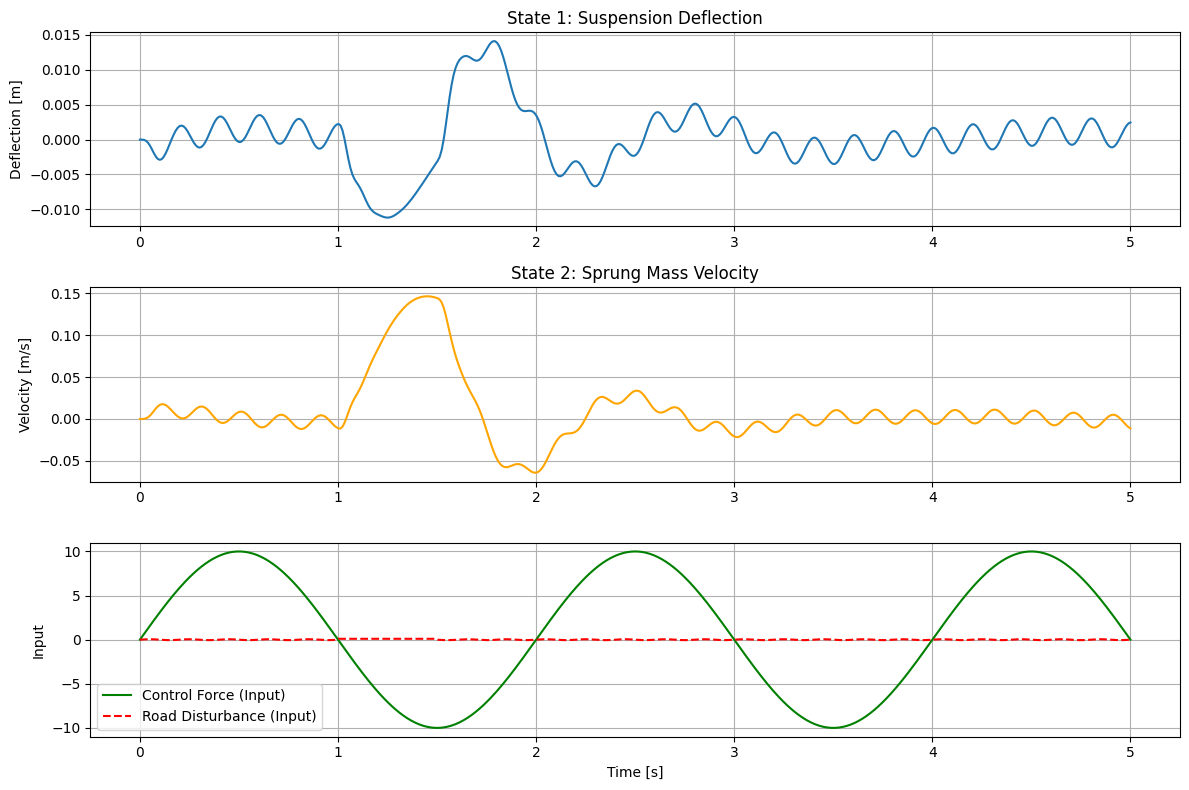

Data generation complete. 'quarter_car_data.csv' saved.
This file contains the ground truth we will try to learn with the PINN.


In [8]:
# ==========================================
# 5. VISUALIZE & SAVE
# ==========================================
# Calculate inputs for saving
u_data = [control_input(ti) for ti in t]
w_data = [road_profile(ti) for ti in t]

# Plot results
plt.figure(figsize=(12, 8))

plt.subplot(3,1,1)
plt.plot(t, x_sol[:,0], label="Suspension Deflection ($z_s - z_u$)")
plt.ylabel("Deflection [m]")
plt.title("State 1: Suspension Deflection")
plt.grid(True)

plt.subplot(3,1,2)
plt.plot(t, x_sol[:,1], label="Body Velocity ($\dot{z}_s$)", color='orange')
plt.ylabel("Velocity [m/s]")
plt.title("State 2: Sprung Mass Velocity")
plt.grid(True)

plt.subplot(3,1,3)
plt.plot(t, u_data, label="Control Force (Input)", color='green')
plt.plot(t, w_data, label="Road Disturbance (Input)", color='red', linestyle='--')
plt.ylabel("Input")
plt.xlabel("Time [s]")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Save Data to CSV for the PINN Project
df = pd.DataFrame(x_sol, columns=['x1', 'x2', 'x3', 'x4'])
df['t'] = t
df['u'] = u_data # Control Input
df['w'] = w_data # Disturbance Input
df.to_csv('quarter_car_data.csv', index=False)

print("Data generation complete. 'quarter_car_data.csv' saved.")
print("This file contains the ground truth we will try to learn with the PINN.")

# Dataset creation- Robust
> here we have also considered the actuator constraints

In [ ]:
import numpy as np
import pandas as pd
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIGURATION
# ==========================================
NUM_EPISODES = 50        # Total distinct simulations
TIME_PER_EPISODE = 10.0  # Duration of each simulation
DT = 0.02                # Sampling time (50Hz)
FILENAME = 'quarter_car_robust_with_actuator.csv'

# Quarter Car Parameters (Fixed)
ms, mu = 250.0, 35.0
ks, bs = 10000.0, 1000.0
ku = 150000.0

# Matrices
A = np.array([
    [0, 1, 0, -1],
    [-ks/ms, -bs/ms, 0, bs/ms],
    [0, 0, 0, 1],
    [ks/mu, bs/mu, -ku/mu, -bs/mu]
])
B = np.array([[0], [1/ms], [0], [-1/mu]])
B_w = np.array([[0], [0], [-1], [0]])

# ==========================================
# 2. RANDOMIZED GENERATION FUNCTIONS
# ==========================================

def get_random_road_profile(t_max, dt, profile_type):
    """Generates a specific road profile function for an episode."""
    t_vals = np.arange(0, t_max, dt)
    
    if profile_type == 'bump':
        # Single bump at random time
        bump_time = np.random.uniform(2, 8)
        w_vals = np.exp(-50*(t_vals - bump_time)**2) * 0.5 # Gaussian bump velocity
    
    elif profile_type == 'rough':
        # Random noise (Rough asphalt)
        w_vals = np.random.normal(0, 0.02, size=len(t_vals))
        
    elif profile_type == 'sine':
        # Sinusoidal road (Washboard)
        freq = np.random.uniform(1, 8) # 1Hz to 8Hz
        w_vals = 0.05 * np.sin(2 * np.pi * freq * t_vals)
        
    else: # Mixed
        w_vals = np.zeros_like(t_vals)

    return t_vals, w_vals

def get_random_control_input(t_vals):
    """Generates random control inputs to excite the system."""
    # APRBS (Amplitude Pseudo-Random Binary Signal) is best for ID, 
    # but smooth random sine waves work well for Neural ODEs.
    # In your data generator script:
        
    # -here it is before we constrained the actuator to have a max and min limit
    #f1 = np.random.uniform(0.1, 2.0)
    #f2 = np.random.uniform(0.1, 2.0)
    #u_vals = 10.0 * np.sin(2*np.pi*f1*t_vals) + 5.0 * np.cos(2*np.pi*f2*t_vals)

    #this is considering the limitation of the actuator also
    MAX_FORCE = 2500.0
    f1 = np.random.uniform(0.1, 2.0)
    f2 = np.random.uniform(0.1, 2.0)
    u_vals = 1000.0 * np.sin(2*np.pi*f1*t_vals) + 2000.0 * np.cos(2*np.pi*f2*t_vals)
    u_vals = np.clip(u_vals, -MAX_FORCE, MAX_FORCE) # This is the crucial constraint
    return u_vals

# ==========================================
# 3. MAIN GENERATION LOOP
# ==========================================
all_data = []

print(f"Generating {NUM_EPISODES} episodes...")

for episode in range(NUM_EPISODES):
    # A. Randomize Initial Conditions (x0)
    # Start with some random suspension deflection (+/- 2cm) and velocity
    x0 = [np.random.uniform(-0.02, 0.02), 
          np.random.uniform(-0.1, 0.1), 
          0, 
          0]
    
    # B. Randomize Environment
    road_type = np.random.choice(['bump', 'rough', 'sine'])
    #road_type = np.random.choice(['bump'])
    t_eval, w_profile = get_random_road_profile(TIME_PER_EPISODE, DT, road_type)
    u_profile = get_random_control_input(t_eval)
    
    # C. Simulation Wrapper for ODEINT
    def system_dynamics(x, t):
        # Find closest index in pre-generated arrays
        idx = int(t / DT) 
        if idx >= len(t_eval): idx = len(t_eval) - 1
        
        u = u_profile[idx]
        w = w_profile[idx]
        
        return A @ x + (B * u).flatten() + (B_w * w).flatten()

    # D. Solve
    x_sol = odeint(system_dynamics, x0, t_eval)
    
    # E. Store Data
    for i in range(len(t_eval)):
        all_data.append({
            'episode_id': episode,
            'time': t_eval[i],
            'x1': x_sol[i, 0], # zs - zu
            'x2': x_sol[i, 1], # zs_dot
            'x3': x_sol[i, 2], # zu - zr
            'x4': x_sol[i, 3], # zu_dot
            'u': u_profile[i],
            'w': w_profile[i],
            'road_type': road_type
        })

# ==========================================
# 4. SAVE TO CSV
# ==========================================
df = pd.DataFrame(all_data)
df.to_csv(FILENAME, index=False)
print(f"Success! Saved {len(df)} data points to '{FILENAME}'.")
print(f"Dataset contains {NUM_EPISODES} episodes with mixed road profiles.")

Generating 10 episodes...
Success! Saved 5000 data points to 'quarter_car_test_data_robust_only_bump.csv'.
Dataset contains 10 episodes with mixed road profiles.


## Robust data visualisation

## visualisation of data without the constraints in actuator

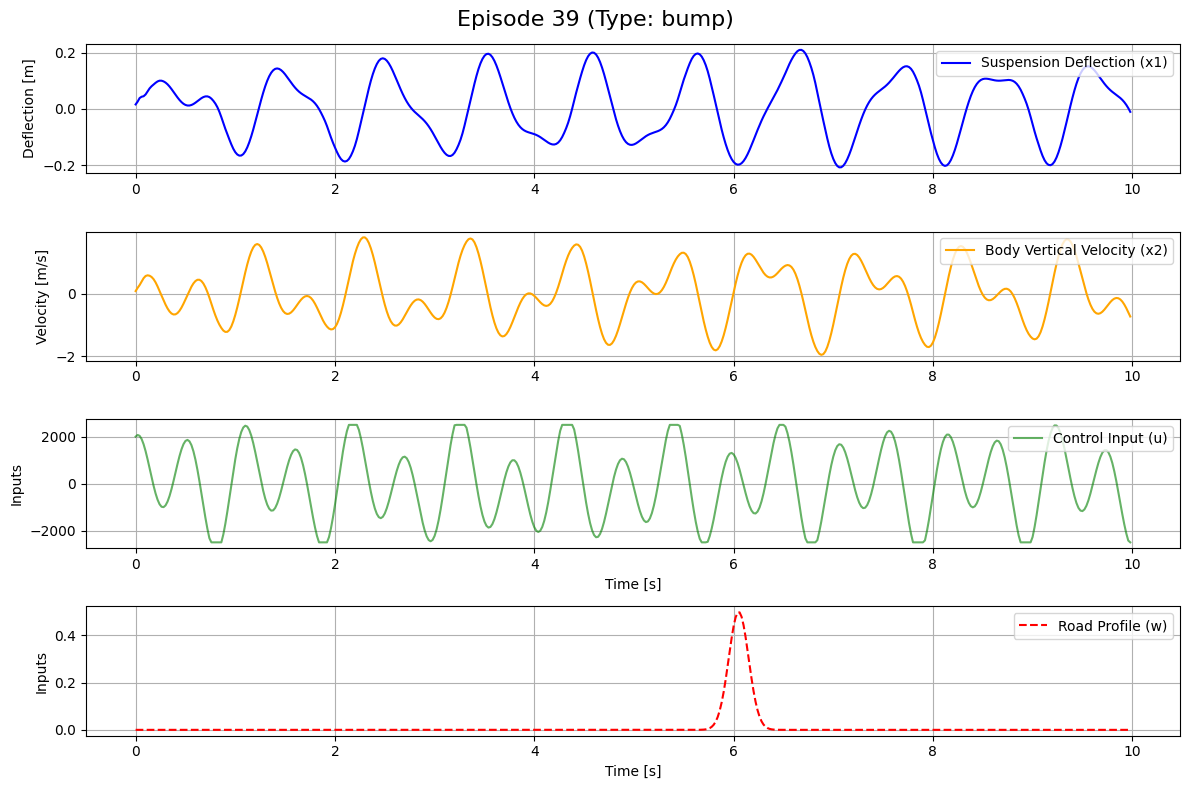

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import random

# Load the full dataset
#df = pd.read_csv('quarter_car_robust_without_actuatorconstraint.csv')
#df = pd.read_csv('quarter_car_test_data_robust_only_bump.csv')
df = pd.read_csv('quarter_car_robust_with_Actuator_constraint.csv')
# Pick a random episode ID
unique_episodes = df['episode_id'].unique()
random_episode = random.choice(unique_episodes)

# Filter data for this episode
subset = df[df['episode_id'] == random_episode]

# Extract values
t = subset['time'].values
x1 = subset['x1'].values # Suspension Deflection
x2 = subset['x2'].values # Body Velocity
u = subset['u'].values   # Control Force
w = subset['w'].values   # Road Disturbance
road_type = subset['road_type'].iloc[0]

# Plot
plt.figure(figsize=(12, 8))
plt.suptitle(f"Episode {random_episode} (Type: {road_type})", fontsize=16)

plt.subplot(4, 1, 1)
plt.plot(t, x1, 'b-', label='Suspension Deflection (x1)')
plt.ylabel('Deflection [m]')
plt.grid(True)
plt.legend(loc='upper right')

plt.subplot(4, 1, 2)
plt.plot(t, x2, 'orange', label='Body Vertical Velocity (x2)')
plt.ylabel('Velocity [m/s]')
plt.grid(True)
plt.legend(loc='upper right')

plt.subplot(4, 1, 3)
plt.plot(t, u, 'g-', alpha=0.6, label='Control Input (u)')
#plt.plot(t, w, 'r--', label='Road Profile (w)')
plt.ylabel('Inputs')
plt.xlabel('Time [s]')
plt.grid(True)
plt.legend(loc='upper right')

plt.subplot(4, 1, 4)
plt.plot(t, w, 'r--', label='Road Profile (w)')
plt.ylabel('Inputs')
plt.xlabel('Time [s]')
plt.grid(True)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

# new randomised testing road profiles- pothole and others

Generating Unseen Road Profiles...
Generated Episode 0: pothole
Generated Episode 1: double_bump
Generated Episode 2: true_speed_bump
Generated Episode 3: cobblestone_patch

Success! Saved to 'unseen_road_test_data.csv'.


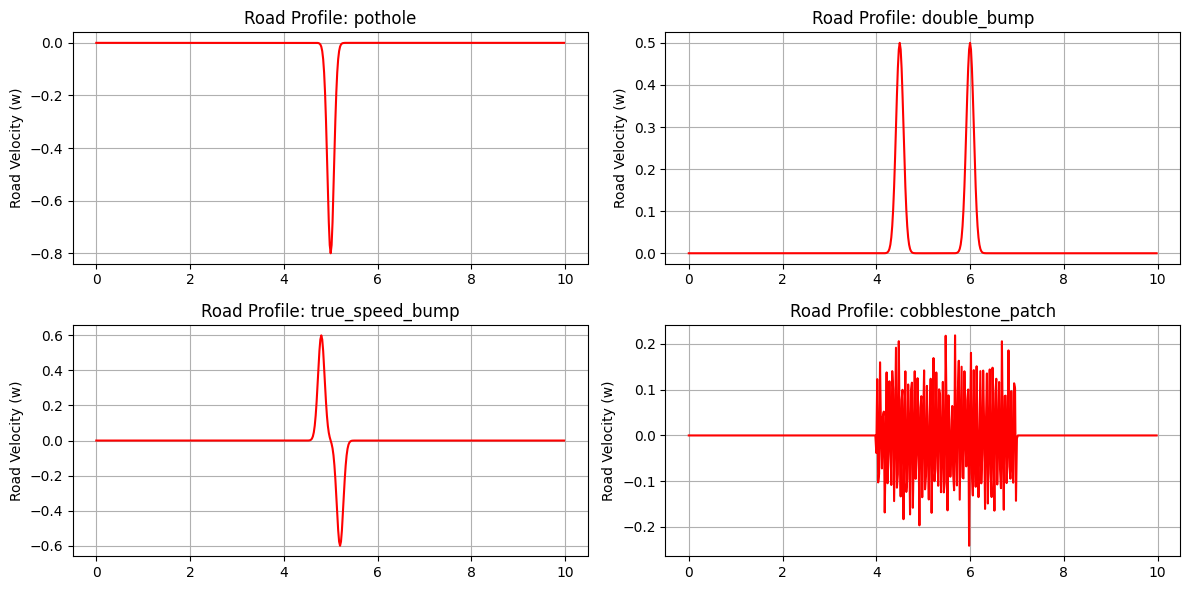

In [22]:
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIGURATION
# ==========================================
TIME_PER_EPISODE = 10.0
DT = 0.02
FILENAME = 'unseen_road_test_data.csv'

ms, mu = 250.0, 35.0
ks, bs = 10000.0, 1000.0
ku = 150000.0

A = np.array([
    [0, 1, 0, -1],
    [-ks/ms, -bs/ms, 0, bs/ms],
    [0, 0, 0, 1],
    [ks/mu, bs/mu, -ku/mu, -bs/mu]
])
B_w = np.array([[0], [0], [-1], [0]])

# ==========================================
# 2. CUSTOM ROAD PROFILES (THE CURVEBALLS)
# ==========================================
def generate_unseen_profiles(t_vals):
    profiles = {}
    
    # 1. Pothole: A sharp, deep negative spike at t=5
    profiles['pothole'] = -0.8 * np.exp(-100 * (t_vals - 5.0)**2)
    
    # 2. Double Bump: Two hits at t=4.5 and t=6.0
    profiles['double_bump'] = 0.5 * np.exp(-80 * (t_vals - 4.5)**2) + 0.5 * np.exp(-80 * (t_vals - 6.0)**2)
    
    # 3. True Speed Bump: Goes up, then abruptly comes back down
    profiles['true_speed_bump'] = 0.6 * np.exp(-100 * (t_vals - 4.8)**2) - 0.6 * np.exp(-100 * (t_vals - 5.2)**2)
    
    # 4. Cobblestone Patch: Flat, then 15Hz violent shaking between 4s and 7s, then flat
    cobble = np.zeros_like(t_vals)
    patch_mask = (t_vals >= 4.0) & (t_vals <= 7.0)
    # Mix of 15Hz sine wave and random noise
    cobble[patch_mask] = 0.15 * np.sin(2 * np.pi * 15 * t_vals[patch_mask]) + np.random.normal(0, 0.03, size=np.sum(patch_mask))
    profiles['cobblestone_patch'] = cobble
    
    return profiles

# ==========================================
# 3. GENERATE AND SAVE DATASET
# ==========================================
t_eval = np.arange(0, TIME_PER_EPISODE, DT)
profiles = generate_unseen_profiles(t_eval)

all_data = []
episode_id = 0

print("Generating Unseen Road Profiles...")

for road_type, w_profile in profiles.items():
    
    def passive_dynamics(t, x):
        # Interpolate to match the solver's continuous time requests
        w = np.interp(t, t_eval, w_profile)
        return A @ x + (B_w * w).flatten()
    
    # Simulate the passive response just to have a complete dataset
    x0 = np.zeros(4)
    sol = solve_ivp(passive_dynamics, [t_eval[0], t_eval[-1]], x0, t_eval=t_eval, method='RK45')
    x_sol = sol.y.T
    
    for i in range(len(t_eval)):
        all_data.append({
            'episode_id': episode_id,
            'time': t_eval[i],
            'x1': x_sol[i, 0], 'x2': x_sol[i, 1],
            'x3': x_sol[i, 2], 'x4': x_sol[i, 3],
            'u': 0.0, # Test dataset has no predefined control
            'w': w_profile[i],
            'road_type': road_type
        })
        
    print(f"Generated Episode {episode_id}: {road_type}")
    episode_id += 1

# Save to CSV
df = pd.DataFrame(all_data)
df.to_csv(FILENAME, index=False)
print(f"\nSuccess! Saved to '{FILENAME}'.")

# Quick plot to visualize what we just made
plt.figure(figsize=(12, 6))
for i, (name, w) in enumerate(profiles.items()):
    plt.subplot(2, 2, i+1)
    plt.plot(t_eval, w, 'r-')
    plt.title(f"Road Profile: {name}")
    plt.ylabel("Road Velocity (w)")
    plt.grid(True)
plt.tight_layout()
plt.show()

Generating Unseen Road Profiles...
Generated Episode 0: pothole
Generated Episode 1: trapezoidal_step
Generated Episode 2: trapezoidal_pothole
Generated Episode 3: complex_step_pair

Success! Saved to 'unseen_road_test_data_increased_amp.csv'.


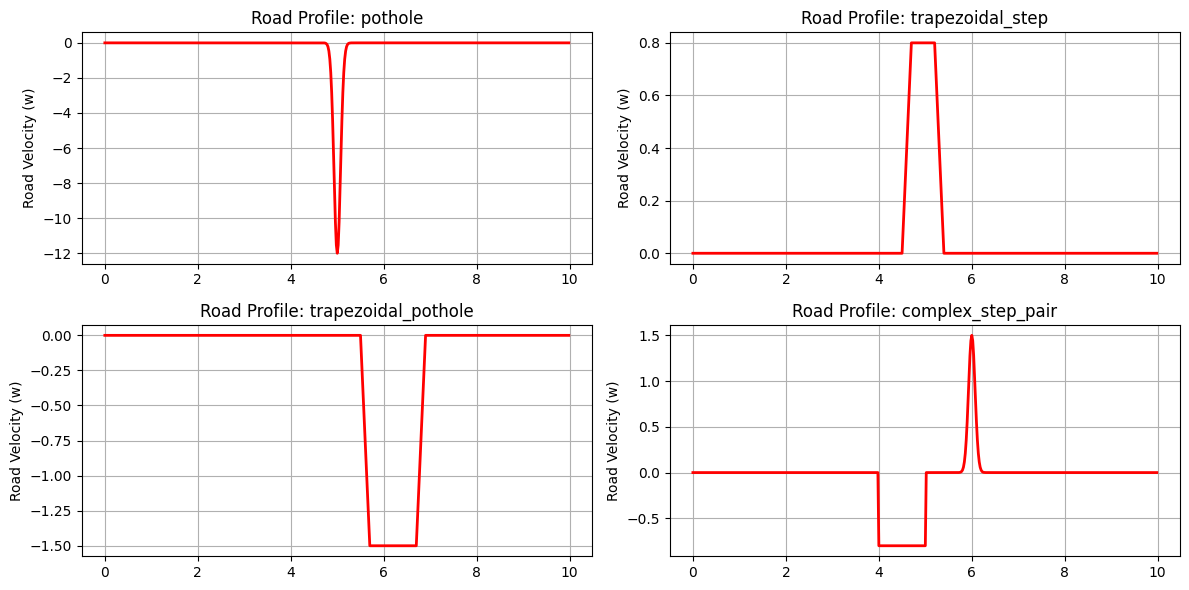

In [1]:
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIGURATION
# ==========================================
TIME_PER_EPISODE = 10.0
DT = 0.02
FILENAME = 'unseen_road_test_data_increased_amp.csv'

# Quarter Car Parameters
ms, mu = 250.0, 35.0
ks, bs = 10000.0, 1000.0
ku = 150000.0

A = np.array([
    [0, 1, 0, -1],
    [-ks/ms, -bs/ms, 0, bs/ms],
    [0, 0, 0, 1],
    [ks/mu, bs/mu, -ku/mu, -bs/mu]
])
B_w = np.array([[0], [0], [-1], [0]])

# ==========================================
# 2. CUSTOM STRUCTURAL PROFILES (THE CURVEBALLS)
# ==========================================
def generate_unseen_profiles(t_vals):
    profiles = {}
    
    # --- Profile 1: Smooth Pothole ---
    profiles['pothole'] = -1.2 * 10 *np.exp(-100 * (t_vals - 5.0)**2)
    
    # --- Profile 2: THE FIX - Trapezoidal Step ---
    trap_step = np.zeros_like(t_vals)
    rise_mask = (t_vals >= 4.5) & (t_vals <= 4.7)
    flat_mask = (t_vals >= 4.7) & (t_vals <= 5.2)
    fall_mask = (t_vals >= 5.2) & (t_vals <= 5.4)
    # Define slopes and flat top
    trap_step[rise_mask] = np.linspace(0.0, 0.8, np.sum(rise_mask))
    trap_step[flat_mask] = 0.8
    trap_step[fall_mask] = np.linspace(0.8, 0.0, np.sum(fall_mask))
    profiles['trapezoidal_step'] = trap_step
    
    # --- Profile 3: Trapezoidal Pothole ---
    trap_pothole = np.zeros_like(t_vals)
    rise_mask = (t_vals >= 5.5) & (t_vals <= 5.7)
    flat_mask = (t_vals >= 5.7) & (t_vals <= 6.7)
    fall_mask = (t_vals >= 6.7) & (t_vals <= 6.9)
    # Define slopes and flat bottom
    trap_pothole[rise_mask] = np.linspace(0.0, -1.5, np.sum(rise_mask))
    trap_pothole[flat_mask] = -1.5
    trap_pothole[fall_mask] = np.linspace(-1.5, 0.0, np.sum(fall_mask))
    profiles['trapezoidal_pothole'] = trap_pothole
    
    # --- Profile 4: Complex Step Pair ---
    step_pair = np.zeros_like(t_vals)
    step1_mask = (t_vals >= 4.0) & (t_vals <= 5.0)
    step2_mask = (t_vals >= 6.0) # Start of second, large event
    step_pair[step1_mask] = -0.8
    # Second event is large jump - use clean Gaussian jump after the step down
    jump = 1.5 * np.exp(-100 * (t_vals - 6.0)**2)
    profiles['complex_step_pair'] = step_pair + jump
    
    return profiles

# ==========================================
# 3. GENERATE AND SAVE DATASET
# ==========================================
t_eval = np.arange(0, TIME_PER_EPISODE, DT)
profiles = generate_unseen_profiles(t_eval)

all_data = []
episode_id = 0

print("Generating Unseen Road Profiles...")

for road_type, w_profile in profiles.items():
    
    def passive_dynamics(t, x):
        # Linear interpolation handles continuous requests beautifully!
        w = np.interp(t, t_eval, w_profile)
        return A @ x + (B_w * w).flatten()
    
    # Simulate passive just for complete dataset
    x0 = np.zeros(4)
    sol = solve_ivp(passive_dynamics, [t_eval[0], t_eval[-1]], x0, t_eval=t_eval, method='RK45')
    x_sol = sol.y.T
    
    for i in range(len(t_eval)):
        all_data.append({
            'episode_id': episode_id,
            'time': t_eval[i],
            'x1': x_sol[i, 0], 'x2': x_sol[i, 1],
            'x3': x_sol[i, 2], 'x4': x_sol[i, 3],
            'u': 0.0, # Test dataset has no predefined control
            'w': w_profile[i],
            'road_type': road_type
        })
        
    print(f"Generated Episode {episode_id}: {road_type}")
    episode_id += 1

# Save to CSV
df = pd.DataFrame(all_data)
df.to_csv(FILENAME, index=False)
print(f"\nSuccess! Saved to '{FILENAME}'.")

# visualize what we just made
plt.figure(figsize=(12, 6))
for i, (name, w) in enumerate(profiles.items()):
    plt.subplot(2, 2, i+1)
    plt.plot(t_eval, w, 'r-', linewidth=2)
    plt.title(f"Road Profile: {name}")
    plt.ylabel("Road Velocity (w)")
    plt.grid(True)
plt.tight_layout()
plt.show()

# Training the neural network
> here we use a switch to decide if we need to use the physics loss or not when training the neural network

## trial training with the single generated dataset

In [ ]:
#%pip install torch torchvision

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 0. HYPERPARAMETERS & SETUP
# ==========================================
USE_PHYSICS_LOSS = True  # Try setting this to False later to see the difference!
LAMBDA_PHYSICS = 1.0     # Weight of the physics loss
EPOCHS = 1000
LEARNING_RATE = 0.005

# Define the physical parameters (same as data generation)
ms, mu = 250.0, 35.0
ks, bs = 10000.0, 1000.0
ku = 150000.0


# Define the Matrices in PyTorch (Requires gradients = False, it's fixed physics)
A_tensor = torch.tensor([
    [0, 1, 0, -1],
    [-ks/ms, -bs/ms, 0, bs/ms],
    [0, 0, 0, 1],
    [ks/mu, bs/mu, -ku/mu, -bs/mu]
], dtype=torch.float32)

B_tensor = torch.tensor([[0], [1/ms], [0], [-1/mu]], dtype=torch.float32)
B_w_tensor = torch.tensor([[0], [0], [-1], [0]], dtype=torch.float32)

# ==========================================
# 1. LOAD AND PREPARE DATA
# ==========================================
print("Loading data...")
df = pd.read_csv('quarter_car_data.csv')

# Extract time and calculate timestep
t = df['t'].values
dt = t[1] - t[0]

# Extract states (x) and inputs (u, w)
X_data = df[['x1', 'x2', 'x3', 'x4']].values
U_data = df[['u']].values
W_data = df[['w']].values

# Calculate true derivatives (x_dot) using numerical differentiation
# We need this as the "Ground Truth" for the Data Loss
X_dot_data = np.gradient(X_data, dt, axis=0)

# Convert everything to PyTorch Tensors
x_tensor = torch.tensor(X_data, dtype=torch.float32)
u_tensor = torch.tensor(U_data, dtype=torch.float32)
w_tensor = torch.tensor(W_data, dtype=torch.float32)
x_dot_true = torch.tensor(X_dot_data, dtype=torch.float32)

# Combine inputs into a single tensor for the Neural Network: [x1, x2, x3, x4, u, w]
# Shape will be (500, 6)
nn_inputs = torch.cat((x_tensor, u_tensor, w_tensor), dim=1)

# ==========================================
# 2. DEFINE THE NEURAL NETWORK
# ==========================================
class QuarterCarNet(nn.Module):
    def __init__(self):
        super(QuarterCarNet, self).__init__()
        # Input: 6 features (4 states + 1 control + 1 disturbance)
        # Output: 4 features (4 state derivatives)
        self.net = nn.Sequential(
            nn.Linear(6, 64),
            nn.Tanh(),       # Tanh is smooth, good for physical systems
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 4) # Predicts x_dot
        )

    def forward(self, x):
        return self.net(x)

model = QuarterCarNet()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
loss_fn = nn.MSELoss()

# ==========================================
# 3. TRAINING LOOP
# ==========================================
print(f"Starting training... (Physics Loss: {USE_PHYSICS_LOSS})")
loss_history = []

for epoch in range(EPOCHS):
    optimizer.zero_grad()
    
    # --- A. Neural Network Prediction ---
    # The network predicts the derivative: x_dot_pred
    x_dot_pred = model(nn_inputs)
    
    # --- B. Data Loss ---
    # Does the network match the numerical derivatives from our CSV?
    loss_data = loss_fn(x_dot_pred, x_dot_true)
    
    # --- C. Physics Loss (The PINN part) ---
    if USE_PHYSICS_LOSS:
        # Calculate what the derivative SHOULD be according to the matrices
        # x_dot = x*A^T + u*B^T + w*B_w^T (Transposed for batch matrix multiplication)
        physics_expected_x_dot = torch.matmul(x_tensor, A_tensor.T) + \
                                 torch.matmul(u_tensor, B_tensor.T) + \
                                 torch.matmul(w_tensor, B_w_tensor.T)
        
        # The physics loss penalizes the network if its prediction doesn't match the math
        loss_physics = loss_fn(x_dot_pred, physics_expected_x_dot)
    else:
        loss_physics = torch.tensor(0.0)
        
    # --- D. Total Loss & Backpropagation ---
    total_loss = loss_data + (LAMBDA_PHYSICS * loss_physics)
    total_loss.backward()
    optimizer.step()
    
    loss_history.append(total_loss.item())
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch:4d} | Total Loss: {total_loss.item():.6f} | Data Loss: {loss_data.item():.6f} | Phys Loss: {loss_physics.item():.6f}")

# Save the model based on the configuration
save_name = "model_pinn.pth" if USE_PHYSICS_LOSS else "model_pure_data.pth"
torch.save(model.state_dict(), save_name)
print(f"Training complete. Model saved as '{save_name}'")

# ==========================================
# 4. PLOT TRAINING CURVE
# ==========================================
plt.figure(figsize=(8, 4))
plt.plot(loss_history, label="Total Training Loss")
plt.yscale('log') # Log scale is best for viewing MSE loss
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title(f"Training Curve (Physics Included: {USE_PHYSICS_LOSS})")
plt.grid(True)
plt.legend()
plt.show()

## testing part- trial

In [ ]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. RE-DEFINE THE NETWORK STRUCTURE
# ==========================================
class QuarterCarNet(nn.Module):
    def __init__(self):
        super(QuarterCarNet, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(6, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 4)
        )
    def forward(self, x):
        return self.net(x)

# Load the trained weights
model = QuarterCarNet()
# NOTE: Make sure the file name matches exactly what you saved!
#model.load_state_dict(torch.load("model_pinn.pth"))
model.load_state_dict(torch.load("model_pure_data.pth"))
model.eval() # Set to evaluation mode

# ==========================================
# 2. LOAD THE GROUND TRUTH DATA
# ==========================================
df = pd.read_csv('quarter_car_data.csv')
t = df['t'].values
dt = t[1] - t[0]

# Extract actual states and inputs for comparison
X_true = df[['x1', 'x2', 'x3', 'x4']].values
U_data = df[['u']].values
W_data = df[['w']].values

# ==========================================
# 3. SIMULATE USING THE NEURAL NETWORK
# ==========================================
print("Simulating trajectory using the Neural Network...")

# Array to hold our network's predictions
X_pred = np.zeros((len(t), 4))

# Set the Initial Condition (Start exactly where the true data starts)
X_pred[0] = X_true[0]

# Step through time using Euler Integration
# Equation: x(t+dt) = x(t) + dt * x_dot_pred
for i in range(len(t) - 1):
    # 1. Get current state and inputs
    x_current = torch.tensor(X_pred[i], dtype=torch.float32).unsqueeze(0)
    u_current = torch.tensor([[U_data[i][0]]], dtype=torch.float32)
    w_current = torch.tensor([[W_data[i][0]]], dtype=torch.float32)

    # 2. Bundle them for the network
    nn_input = torch.cat((x_current, u_current, w_current), dim=1)

    # 3. Ask network to predict the derivative (x_dot)
    with torch.no_grad():
        x_dot_pred = model(nn_input).numpy()[0]

    # 4. Integrate forward in time
    X_pred[i+1] = X_pred[i] + (x_dot_pred * dt)

# ==========================================
# 4. VISUALIZE RESULTS (NN vs Ground Truth)
# ==========================================
plt.figure(figsize=(12, 8))
plt.suptitle("Neural Network Simulation vs Ground Truth Physics", fontsize=16)

# Plot x1: Suspension Deflection
plt.subplot(2, 2, 1)
plt.plot(t, X_true[:, 0], 'k-', linewidth=2, label="True Physics (ODE)")
plt.plot(t, X_pred[:, 0], 'r--', linewidth=2, label="Neural Network")
plt.title("State 1: Suspension Deflection ($z_s - z_u$)")
plt.ylabel("[m]")
plt.legend()
plt.grid(True)

# Plot x2: Sprung Mass Velocity
plt.subplot(2, 2, 2)
plt.plot(t, X_true[:, 1], 'k-', linewidth=2, label="True Physics (ODE)")
plt.plot(t, X_pred[:, 1], 'b--', linewidth=2, label="Neural Network")
plt.title("State 2: Body Velocity ($\dot{z}_s$)")
plt.ylabel("[m/s]")
plt.legend()
plt.grid(True)

# Plot x3: Tire Deflection
plt.subplot(2, 2, 3)
plt.plot(t, X_true[:, 2], 'k-', linewidth=2, label="True Physics (ODE)")
plt.plot(t, X_pred[:, 2], 'g--', linewidth=2, label="Neural Network")
plt.title("State 3: Tire Deflection ($z_u - z_r$)")
plt.xlabel("Time [s]")
plt.ylabel("[m]")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Training pipeline with the robust dataset and with data normalisation also!